In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.lines import lineStyles

from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [2]:
zambia_inequality = pd.read_csv('../../data/Zambia_Inequality/inequality.csv')
lic_inequality = pd.read_csv('../../data/LIC_Inequality/inequality.csv')

In [3]:
zambia_clean, zambia_lookup = clean_wb_wide(zambia_inequality, drop_top_rows=0)
lic_clean, lic_lookup = clean_wb_wide(lic_inequality, drop_top_rows=0)

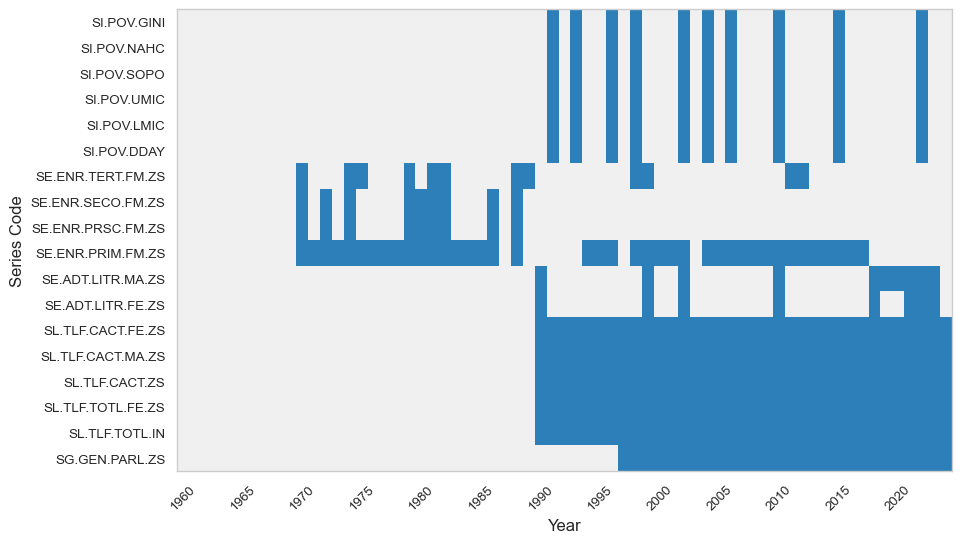

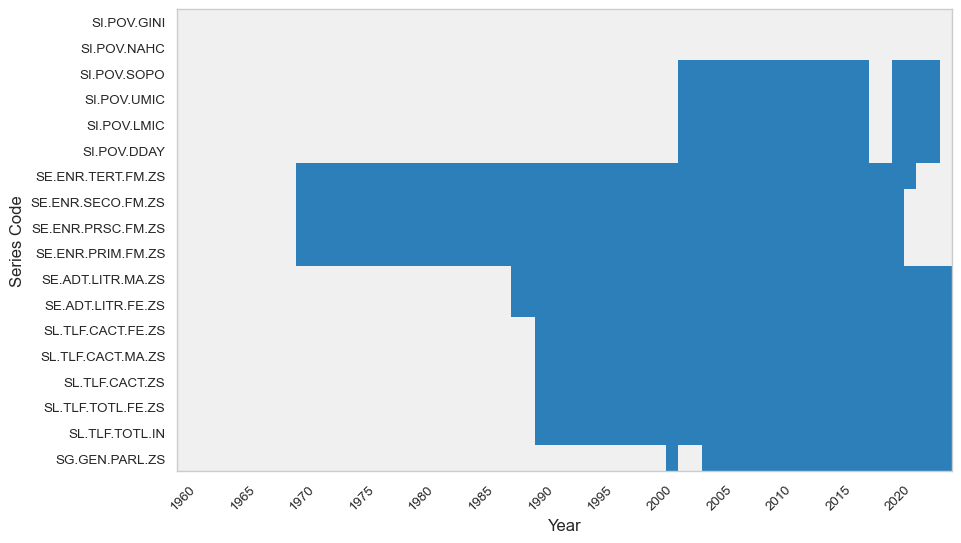

In [4]:
availability_zambia, fig_zambia, ax_zambia = plot_missing_heatmap(
    zambia_clean,
    lookup=zambia_lookup
)
availability_lic, fig_lic, ax_lic = plot_missing_heatmap(
    lic_clean,
    lookup=lic_lookup
)

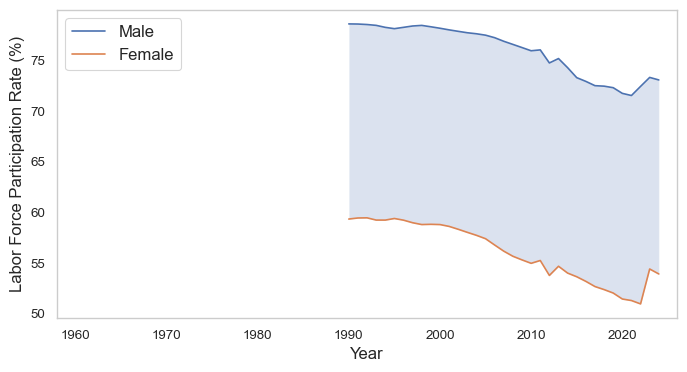

In [10]:
# gender gap in labor force participation rate
# SL.TLF.CACT.FE.ZS: female
# SL.TLF.CACT.MA.ZS: male
# df = inequality_clean.dropna(subset=['SL.TLF.CACT.FE.ZS', 'SL.TLF.CACT.MA.ZS'])
df_lic = lic_clean.dropna(subset=['SL.TLF.CACT.FE.ZS', 'SL.TLF.CACT.MA.ZS'])
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_lic['Year'], df_lic['SL.TLF.CACT.MA.ZS'], label='Male')
ax.plot(df_lic['Year'], df_lic['SL.TLF.CACT.FE.ZS'], label='Female')

ax.fill_between(df_lic['Year'], df_lic['SL.TLF.CACT.MA.ZS'], df_lic['SL.TLF.CACT.FE.ZS'], alpha=0.2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Labor Force Participation Rate (%)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(False)

ax.set_xlim(1958, 2026)

fig.savefig(
    "../figures/LIC/inequality/labor_force_part_gender.pdf",
    format="pdf",
    bbox_inches="tight"
)

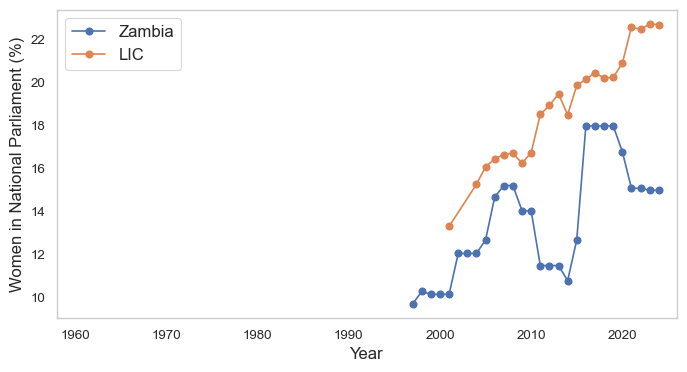

In [11]:
# gender gap in national parliament seats
# SG.GEN.PARL.ZS: Proportion of seats held by women in national parliaments (%)
# df = inequality_clean.dropna(subset=['SG.GEN.PARL.ZS'])
df_zambia = zambia_clean.dropna(subset=['SG.GEN.PARL.ZS'])
df_lic = lic_clean.dropna(subset=['SG.GEN.PARL.ZS'])
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_zambia['Year'], df_zambia['SG.GEN.PARL.ZS'], marker='o', label='Zambia')
ax.plot(df_lic['Year'], df_lic['SG.GEN.PARL.ZS'], marker='o', label='LIC')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Women in National Parliament (%)', fontsize=12)
ax.grid(False)
ax.legend(fontsize=12)

ax.set_xlim(1958, 2026)

fig.savefig(
    "../figures/LIC/inequality/women_national_parliaments.pdf",
    format="pdf",
    bbox_inches="tight"
)